In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")



In [43]:


# Load dataset
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [44]:
df.shape

(10000, 14)

### understanding dataset

In [45]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### missing values & duplicates

In [46]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicate Rows: 0


### target distribution

Machine failure
0    9661
1     339
Name: count, dtype: int64


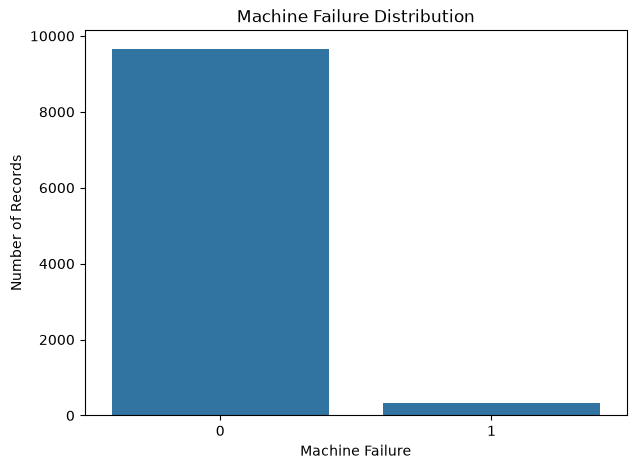

In [47]:
print(df["Machine failure"].value_counts())

plt.figure(figsize=(7, 5))

sns.countplot(
    x="Machine failure",
    data=df
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Records")
plt.show()

### EDA visualisation

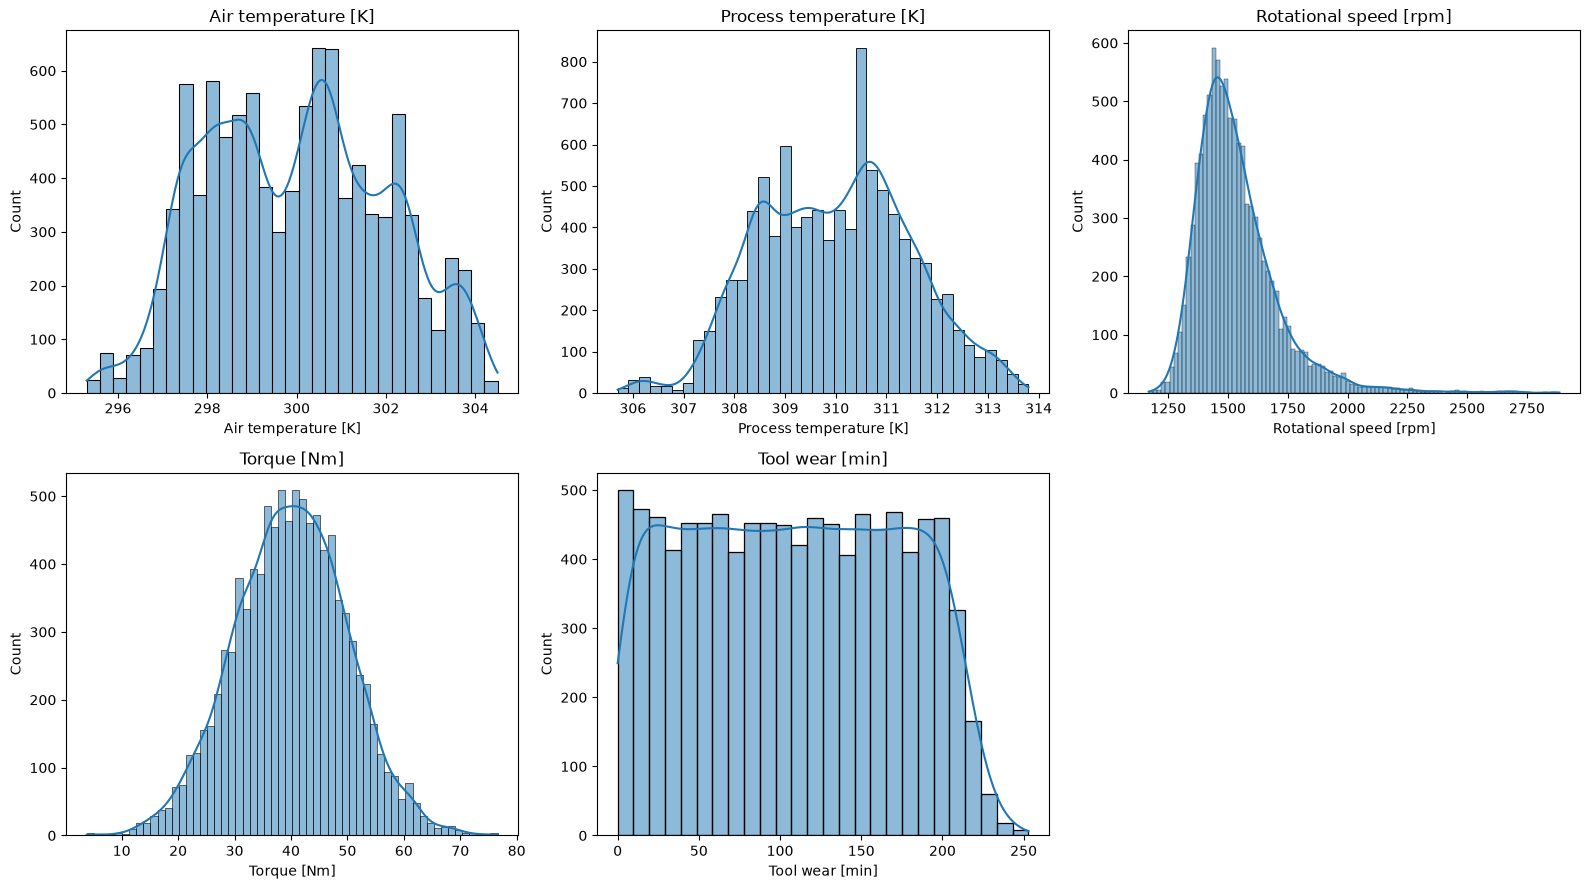

In [48]:
numeric_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, numeric_columns):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

axes.flat[-1].axis("off")

plt.tight_layout()
plt.show()

### correlation heatmap

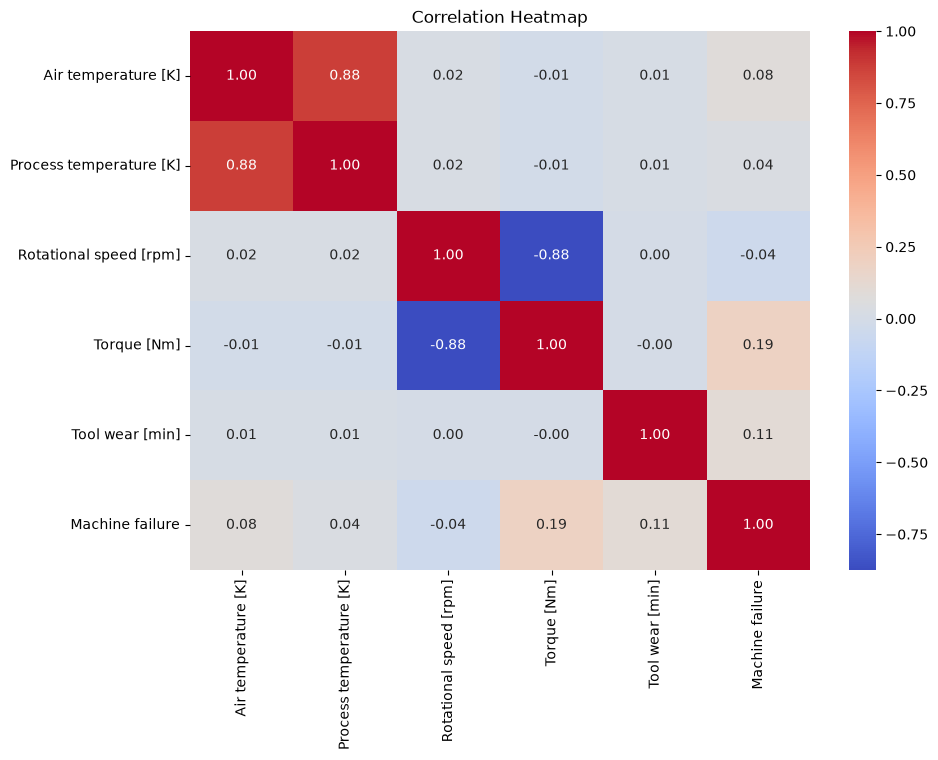

In [49]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_columns + ["Machine failure"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### preparing features and target

In [50]:
# Target
y = df["Machine failure"]

# Remove identifiers and leakage-prone failure-type columns
X = df.drop(
    columns=[
        "Machine failure",
        "UDI",
        "Product ID",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ]
)

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nFeature Shape:", X.shape)

Features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Target:
Machine failure

Feature Shape: (10000, 6)


#### encoding & train test split

In [51]:
from sklearn.model_selection import train_test_split

# Convert categorical Type into dummy variables
X = pd.get_dummies(
    X,
    columns=["Type"],
    drop_first=True
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

Training Data: (8000, 7)
Testing Data: (2000, 7)

Training Target Distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64


### handling imbalance

In [52]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE:
Machine failure
0    7729
1     271
Name: count, dtype: int64

After SMOTE:
Machine failure
0    7729
1    7729
Name: count, dtype: int64


### train multiple calssification model

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    
    "Support Vector Machine": SVC(
        probability=True,
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():

    model.fit(
        X_train_balanced,
        y_train_balanced
    )

    trained_models[name] = model

print("All models trained successfully!")

All models trained successfully!


### model comparision

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        )
    })

results = pd.DataFrame(results)

results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Random Forest,0.9630,0.471154,0.720588,0.569767,0.958470
4,Gradient Boosting,0.9385,0.341040,0.867647,0.489627,0.963810
2,Decision Tree,0.9480,0.352459,0.632353,0.452632,0.795731
0,Logistic Regression,0.8700,0.168966,0.720588,0.273743,0.878798
1,Support Vector Machine,0.7915,0.129512,0.897059,0.226345,0.909070


### model comparision graph

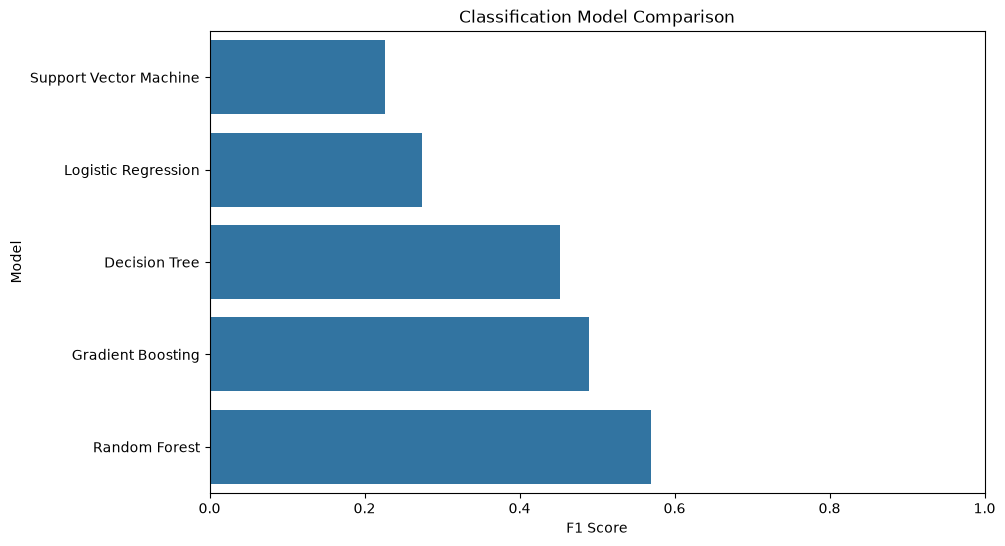

In [55]:
plt.figure(figsize=(10, 6))

results_sorted = results.sort_values(
    "F1 Score",
    ascending=True
)

sns.barplot(
    data=results_sorted,
    x="F1 Score",
    y="Model"
)

plt.title("Classification Model Comparison")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.show()

###  Confusion Matrix + ROC Curve

Best Model: Random Forest


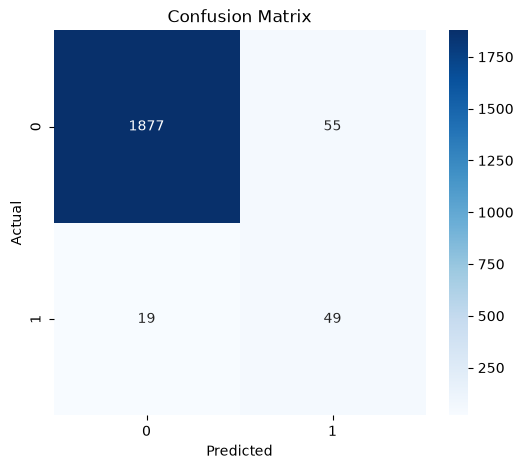

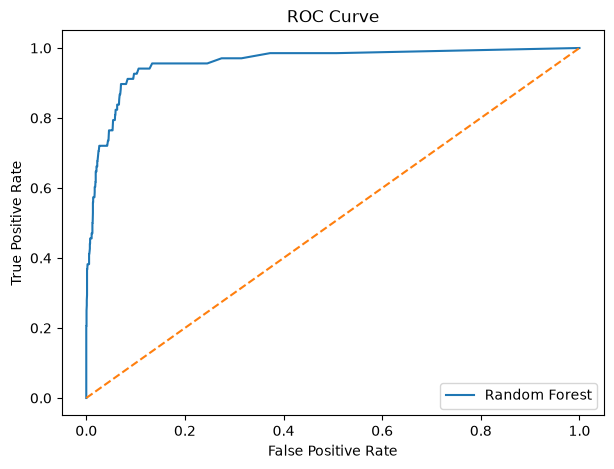

In [56]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Best Model:", best_model_name)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ROC Curve
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"{best_model_name}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### feature importance

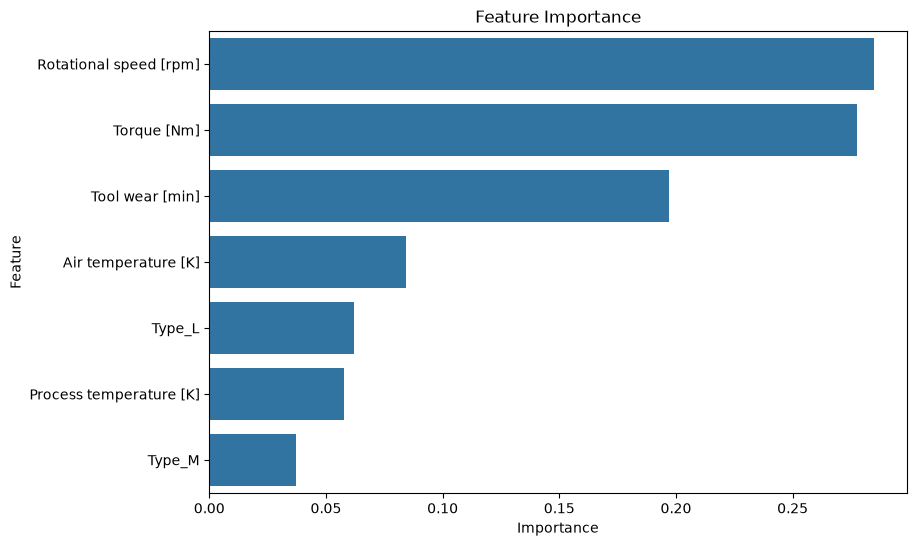

In [57]:
if hasattr(best_model, "feature_importances_"):
    
    importance = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(9, 6))

    sns.barplot(
        x=importance.values,
        y=importance.index
    )

    plt.title("Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.show()

else:
    print(
        "Feature importance graph is not directly available "
        "for the selected model."
    )

### saving best model

In [58]:
import pickle

# Save model
with open("machine_failure_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Save feature columns
with open("machine_failure_features.pkl", "wb") as file:
    pickle.dump(X.columns.tolist(), file)

print("Best model saved successfully!")
print("Selected Model:", best_model_name)

Best model saved successfully!
Selected Model: Random Forest


### test one prediction

In [59]:
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)[0]
probability = best_model.predict_proba(sample)[0][1]

print("Selected Model:", best_model_name)
print("Prediction:", prediction)
print("Failure Probability:", round(probability * 100, 2), "%")

if prediction == 1:
    print("⚠️ Machine Failure Predicted")
else:
    print("✅ No Machine Failure Predicted")

Selected Model: Random Forest
Prediction: 1
Failure Probability: 77.0 %
⚠️ Machine Failure Predicted


In [60]:
import pickle

# Save best model
with open("machine_failure_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Save feature columns
with open("machine_failure_features.pkl", "wb") as file:
    pickle.dump(X.columns.tolist(), file)

print("Model and feature files saved successfully!")
print("Selected Model:", best_model_name)

Model and feature files saved successfully!
Selected Model: Random Forest
